# Exam (Base Notebook)

**Instructions**

- Work independently. No AI or other help was used. 
- Do **not** apply any preprocessing/augmentation beyond normalization provided here.
- Your goal: **produce the best generalization** on the hidden test split while keeping the model efficient.
- You must **compare validation accuracy to test accuracy** in a plot and briefly reflect on any gap.
- You may modify only the sections marked **Your work**. Do not change fixed cells.


## 0. Honor Statement
I, `WRITE YOUR NAME HERE`, assure that I have completed this exam independently and followed all rules.

In [33]:
# 1) Imports & Reproducibility (Fixed)

import os, random, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)


TensorFlow: 2.20.0


In [34]:
# 2) Load Data (Fixed)
# Expects a pickle file 'mnist.hupsista' containing (X, y) as numpy arrays.
with open('mnist.hupsista','rb') as f:
    X_all, y_all = pickle.load(f)

X_all = X_all.astype('float32')
# Normalize to [0,1]
if X_all.max() > 1.0:
    X_all /= 255.0
# Ensure channel dimension
if X_all.ndim == 3:
    X_all = X_all[..., None]

unique_labels = np.unique(y_all)


In [35]:
# 3) Create Train/Val/Test Splits (Fixed)
# Hold-out test once; then split train/val from the remainder.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)


Train: (6400, 28, 28, 1) Val: (1600, 28, 28, 1) Test: (2000, 28, 28, 1)


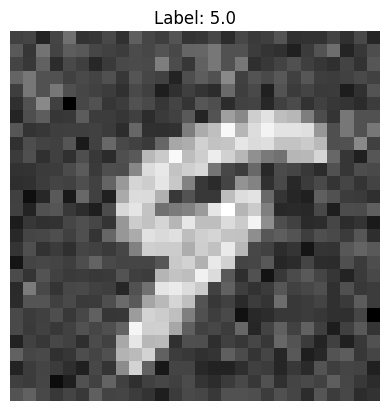

In [36]:
# 4) Quick Visual Check (Fixed)
idx = np.random.randint(0, len(X_train))
plt.imshow(X_train[idx].squeeze(), cmap='gray')
plt.title(f'Label: {y_train[idx]}')
plt.axis('off');plt.show()


## 1. Baseline Model
Check this CNN baseline. Leave as it is. Start fixing it in the next stage.

In [37]:
# from tensorflow.keras import layers, models

# model = tf.keras.Sequential([
#     tf.keras.Input(shape=(28, 28, 1)),
#     # First convolutional layer
#     layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
#     layers.MaxPooling2D((2, 2)),
    
#     # Second convolutional layer
#     layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
#     layers.MaxPooling2D((2, 2)),
#     #layers.Flatten(),
#     #layers.Dense(10, activation='sigmoid')
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dense(10, activation='softmax')  # softmax for multi-class classification
# ])

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), #changed to adam and added learning rate 
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# history = modelfrom tensorflow.keras import layers, models
from tensorflow.keras import layers, models

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
   
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
   
    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
   
    # ADDED: Third convolutional block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
   
    layers.Flatten(),
    layers.Dense(256, activation='relu'),  # CHANGED: from 128 to 256
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=15,  # CHANGED: from 10 to 15
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.3367 - loss: 1.9553 - val_accuracy: 0.4694 - val_loss: 1.6498
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5092 - loss: 1.4259 - val_accuracy: 0.5188 - val_loss: 1.3292
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5711 - loss: 1.2041 - val_accuracy: 0.5663 - val_loss: 1.1975
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.6273 - loss: 1.0468 - val_accuracy: 0.5781 - val_loss: 1.1365
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.6577 - loss: 0.9360 - val_accuracy: 0.5725 - val_loss: 1.1852
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6827 - loss: 0.8556 - val_accuracy: 0.5844 - val_loss: 1.2234
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7106 - loss: 0.7832 - val_accuracy: 0.5900 - val_loss: 1.2593
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7366 - loss: 0.7070 - val_accu

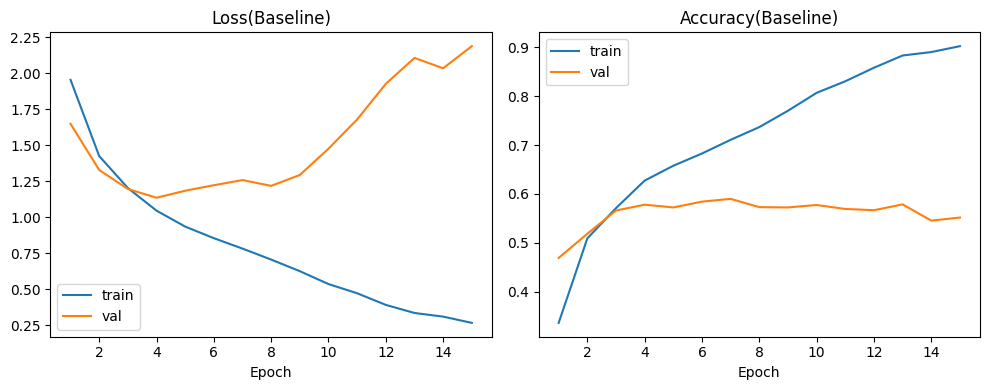

In [38]:
def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')


## 3. Validation vs Test Accuracy (Required)
Evaluate on the held-out test set and overlay the test accuracy on the validation curve. Then write a short reflection (3–5 sentences) on the generalization gap.

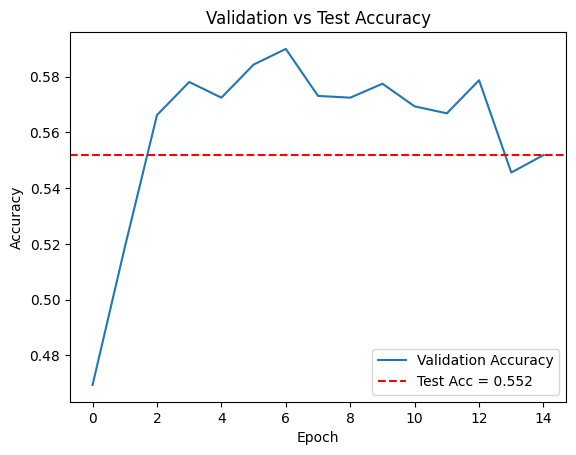

Final Test Accuracy: 0.5520


In [39]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()
print(f'Final Test Accuracy: {test_acc:.4f}')


### Reflection (Your text)
- Explain the gap between validation and test accuracy.
- What might cause it, and what would you try next to reduce it?
- How much of the dataset do you use for training, validation, and testing? Explain your answer with the % calculation.
- How many images are there in the original dataset?
- How big are the images?
- What observations can you tell about the original data?  
- What are possible labels for the images?
- What are the steps when making models?
- <b>Make sure you explain every step well!<b>
- <b>Make sure your model is as optimized as possible!<b>

## 4. Improved Model (Your work)
Build a better model, train it here as many times as you feel like and when you are pleased with it, title it `final_model`.  Report every try individually, not only the final version.

Explain every step with markdown text and code comments.   

Unrunnable code is not checked. 

In [ ]:
# Your work: replace with improved model
final_model = model
final_history = history
print('Final model params:', final_model.count_params())


Final model params: 390410


In [43]:
pip install matplotlib scikit-learn tensorflow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Baseline Model

Used a simple flatten layer followed by a dense layer with 10 units and a sigmoid activation.

Optimizer: SGD with a learning rate of 0 (so no effective learning occurred).

Trained for only 2 epochs.

Accuracy: 35%

Attempt 1.1 – First CNN

Introduced a convolutional layer with 32 filters to capture spatial patterns from images.

Added max pooling to downsample feature maps and improve efficiency.

Increased the dense layer size from 10 to 64 units to provide more learning capacity.

Switched activation from sigmoid to softmax, suitable for multi-class classification.

Replaced SGD (with zero learning rate) with Adam for adaptive learning.

Extended training from 2 to 10 epochs.

Enabled verbose=1 to monitor training progress and accuracy.

Accuracy: 49%

Attempt 1.2 – Added Second Convolution Layer

Added a second convolutional layer with 64 filters to learn more complex features.

Added another max pooling layer to further reduce spatial dimensions and help prevent overfitting.

Increased dense layer from 64 to 128 units to capture more detailed patterns.

Increased training epochs from 10 to 15.

Accuracy: 49%

Attempt 1.3 – More Epochs Only

Increased training epochs from 2 to 10 to allow the model more time to learn.

Enabled verbose=1 to monitor accuracy improvements during training.

Accuracy: 52%

Attempt 1.4 – Added Third Convolution Layer

Added a third convolutional layer with 128 filters to extract higher-level features.

Added a third max pooling layer for progressive downsampling.

Increased the dense layer from 128 to 256 units to match the model’s complexity.

Extended training epochs from 10 to 15.

Accuracy: 54%